# 1.1 CST3133 Data Science Coursework Section 1 - Predicting CS:GO games using Traditional Machine Learning Methods

In [ ]:
#Install packages if needed (uncomment if running in Google Colab and packages are missing)
!pip install pandas numpy matplotlib seaborn scikit-learn
!pip install catboost





[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Verify installations
import sys
print(f"Python version: {sys.version.split()[0]}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
try:
    import sklearn
    print(f"Scikit-learn version: {sklearn.__version__}")
except:
    print("Scikit-learn: Installed")
print("\nAll required packages are available.")

Python version: 3.14.3
Pandas version: 3.0.2
NumPy version: 2.4.4
Scikit-learn version: 1.8.0

All required packages are available.


## 1.1.1 Load the Noisy CS:GO Games Dataset

In [3]:
# Load the dataset
df = pd.read_csv('csgo_games_noisy.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst few rows:")
df.head()

Dataset Shape: (3787, 170)

Column Names:
['match_date', 'team_1', 'team_2', 't1_points', 't2_points', 't1_world_rank', 't2_world_rank', 't1_h2h_win_perc', 't2_h2h_win_perc', 'winner', 't1_player1_rating', 't1_player1_impact', 't1_player1_kdr', 't1_player1_dmr', 't1_player1_kpr', 't1_player1_apr', 't1_player1_dpr', 't1_player1_spr', 't1_player1_opk_ratio', 't1_player1_opk_rating', 't1_player1_wins_perc_after_fk', 't1_player1_fk_perc_in_wins', 't1_player1_multikill_perc', 't1_player1_rating_at_least_one_perc', 't1_player1_is_sniper', 't1_player1_clutch_win_perc', 't1_player2_rating', 't1_player2_impact', 't1_player2_kdr', 't1_player2_dmr', 't1_player2_kpr', 't1_player2_apr', 't1_player2_dpr', 't1_player2_spr', 't1_player2_opk_ratio', 't1_player2_opk_rating', 't1_player2_wins_perc_after_fk', 't1_player2_fk_perc_in_wins', 't1_player2_multikill_perc', 't1_player2_rating_at_least_one_perc', 't1_player2_is_sniper', 't1_player2_clutch_win_perc', 't1_player3_rating', 't1_player3_impact', 't1_p

,match_date,team_1,team_2,t1_points,t2_points,t1_world_rank,t2_world_rank,t1_h2h_win_perc,t2_h2h_win_perc,winner,...,t2_player5_dpr,t2_player5_spr,t2_player5_opk_ratio,t2_player5_opk_rating,t2_player5_wins_perc_after_fk,t2_player5_fk_perc_in_wins,t2_player5_multikill_perc,t2_player5_rating_at_least_one_perc,t2_player5_is_sniper,t2_player5_clutch_win_perc
0,2016-12-18,CLOUD9,HELLRAISERS,13,16,9,20,0.500000,0.500000,t2,...,0.63,0.10,NaN,0.92,0.733,0.104,0.147018,0.528,False,0.666667
1,2016-12-18,IMMORTALS,G2,17,19,13,10,0.500000,0.500000,t2,...,0.69,0.09,0.85,0.96,0.739,0.147,0.135810,0.438,True,0.406250
2,2016-12-18,MOUSESPORTS,IMMORTALS,16,3,12,13,0.500000,0.500000,t1,...,0.67,0.07,0.79,0.94,0.723,0.129,0.148257,0.526,False,0.733333
3,2016-12-18,DIGNITAS,G2,16,9,6,10,0.416667,0.583333,t1,...,0.69,0.09,0.85,0.96,0.739,0.147,0.135810,0.438,True,0.406250
4,2016-12-18,OPTIC,HELLRAISERS,16,10,4,20,0.500000,0.500000,t1,...,0.63,0.10,1.05,0.92,0.733,0.104,0.147018,0.528,False,0.666667


In [4]:
# Dataset overview
print("Dataset Info:")
df.info()
print("\n" + "="*50)
print("Target Variable Distribution:")
print(df['winner'].value_counts())
print("\n" + "="*50)
print("Basic Statistics:")
df.describe()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 3787 entries, 0 to 3786
Columns: 170 entries, match_date to t2_player5_clutch_win_perc
dtypes: bool(10), float64(152), int64(4), str(4)
memory usage: 4.7 MB

Target Variable Distribution:
winner
t1      1921
t2      1842
draw      24
Name: count, dtype: int64

Basic Statistics:


,t1_points,t2_points,t1_world_rank,t2_world_rank,t1_h2h_win_perc,t2_h2h_win_perc,t1_player1_rating,t1_player1_impact,t1_player1_kdr,t1_player1_dmr,...,t2_player5_apr,t2_player5_dpr,t2_player5_spr,t2_player5_opk_ratio,t2_player5_opk_rating,t2_player5_wins_perc_after_fk,t2_player5_fk_perc_in_wins,t2_player5_multikill_perc,t2_player5_rating_at_least_one_perc,t2_player5_clutch_win_perc
count,3787.000000,3787.000000,3787.000000,3787.000000,3787.000000,3787.000000,3787.000000,3787.000000,3787.000000,3787.000000,...,3787.000000,3787.000000,3787.000000,3572.000000,3787.000000,3786.000000,3787.000000,3787.000000,3540.000000,3787.000000
mean,7.829945,7.687351,8.836810,9.836546,0.517780,0.473839,1.185255,1.230552,1.211069,78.839454,...,0.134177,0.668492,0.085883,0.880725,0.933752,0.743385,0.119163,0.142620,0.478714,0.593293
std,6.869174,6.894263,5.550307,5.616128,0.228813,0.760342,0.067781,0.106033,0.112633,111.878129,...,0.019367,0.034841,0.015337,0.174280,0.072848,0.048824,0.157763,0.015386,0.100256,0.143225
min,0.000000,0.000000,1.000000,1.000000,0.000000,-9.774259,0.970000,0.880000,0.870000,-822.653974,...,0.040000,0.530000,0.020000,0.000000,0.490000,0.375000,-1.566273,0.059829,0.000000,0.000000
25%,2.000000,2.000000,4.000000,5.000000,0.389566,0.333333,1.140000,1.160000,1.130000,79.100000,...,0.120000,0.650000,0.080000,0.770000,0.890000,0.715250,0.105000,0.132526,0.415000,0.500000
50%,6.000000,5.000000,8.000000,10.000000,0.500000,0.500000,1.180000,1.230000,1.200000,82.400000,...,0.130000,0.670000,0.090000,0.870000,0.930000,0.747000,0.121000,0.143365,0.483000,0.600000
75%,16.000000,16.000000,13.000000,15.000000,0.666667,0.612903,1.230000,1.300000,1.270000,85.300000,...,0.150000,0.690000,0.100000,0.980000,0.980000,0.775000,0.139000,0.152723,0.544000,0.676471
max,34.000000,34.000000,22.000000,22.000000,1.000000,9.595601,1.440000,1.790000,1.600000,874.140681,...,0.210000,0.810000,0.150000,2.050000,1.200000,1.000000,1.773913,0.194529,0.795000,1.000000


## 1.1.2 Data Preprocessing (10%)

### Step 1: Handle Missing Values
We will identify and handle missing values appropriately.

Missing Values Summary:
                                  Column  Missing Count  Percentage
15                        t1_player1_apr            257    6.786374
167  t2_player5_rating_at_least_one_perc            247    6.522313
106                    t2_player2_rating            243    6.416689
76                        t1_player5_kdr            243    6.416689
89            t1_player5_clutch_win_perc            241    6.363876
108                       t2_player2_kdr            239    6.311064
44                        t1_player3_kdr            238    6.284658
97                        t2_player1_spr            238    6.284658
64                        t1_player4_dpr            234    6.179034
25            t1_player1_clutch_win_perc            233    6.152627
21            t1_player1_fk_perc_in_wins            232    6.126221
36         t1_player2_wins_perc_after_fk            230    6.073409
77                        t1_player5_dmr            226    5.967785
18                  t1_p

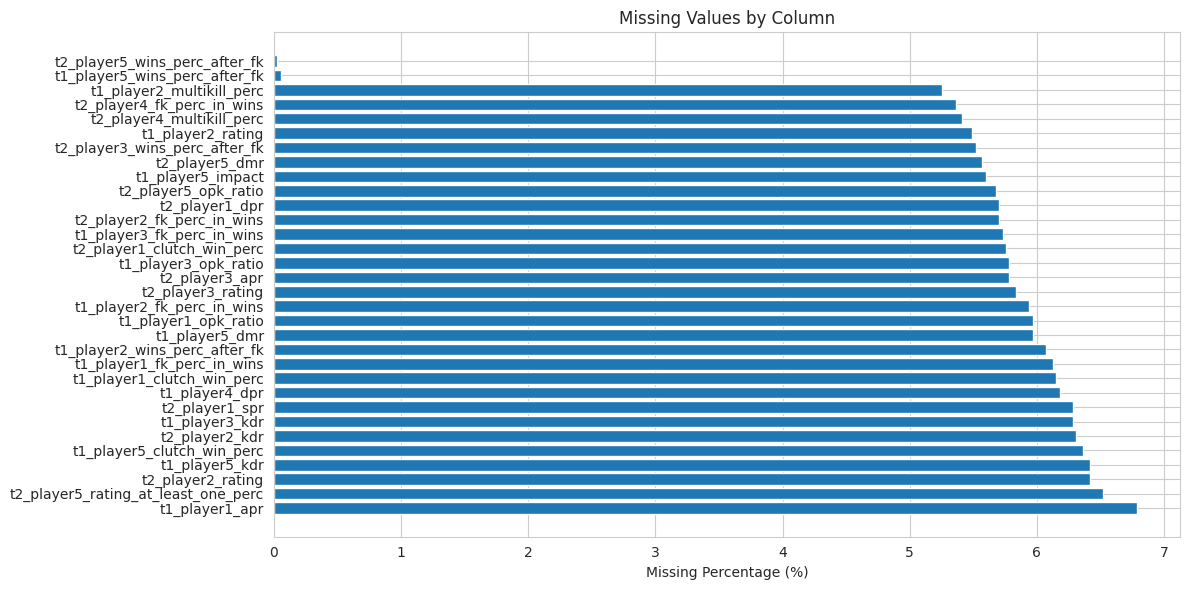

In [5]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Count': missing_values.values,
    'Percentage': missing_percentage.values
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

print("Missing Values Summary:")
print(missing_df)

# Visualize missing values
if len(missing_df) > 0:
    plt.figure(figsize=(12, 6))
    plt.barh(missing_df['Column'], missing_df['Percentage'])
    plt.xlabel('Missing Percentage (%)')
    plt.title('Missing Values by Column')
    plt.tight_layout()
    plt.show()

In [6]:
# Use dataset as-is (dataset already contains any natural noise/missing values)
df_noisy = df.copy()
print("Missing values in dataset:", df_noisy.isnull().sum().sum())

Missing values in dataset: 6743


In [7]:
# Handle missing values
# For numerical columns: use median imputation
# For categorical columns: use mode imputation

df_processed = df_noisy.copy()

# Separate numerical and categorical columns
numerical_cols = df_processed.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_processed.select_dtypes(include=['object', 'bool']).columns.tolist()

# Impute numerical columns with median
numerical_imputer = SimpleImputer(strategy='median')
df_processed[numerical_cols] = numerical_imputer.fit_transform(df_processed[numerical_cols])

# Impute categorical columns with mode
for col in categorical_cols:
    if df_processed[col].isnull().sum() > 0:
        mode_value = df_processed[col].mode()[0] if len(df_processed[col].mode()) > 0 else 'Unknown'
        df_processed[col].fillna(mode_value, inplace=True)

print("Missing values after imputation:", df_processed.isnull().sum().sum())
print("\nImputation Strategy:")
print("- Numerical columns: Median imputation")
print("- Categorical columns: Mode imputation")

Missing values after imputation: 0

Imputation Strategy:
- Numerical columns: Median imputation
- Categorical columns: Mode imputation


### Step 2: Feature Engineering and Encoding
We will create logical features and encode categorical variables.

In [8]:
# Feature Engineering: Create aggregated team statistics
df_features = df_processed.copy()

# Calculate average team ratings
t1_rating_cols = [col for col in df_features.columns if 't1_player' in col and 'rating' in col]
t2_rating_cols = [col for col in df_features.columns if 't2_player' in col and 'rating' in col]

df_features['t1_avg_rating'] = df_features[t1_rating_cols].mean(axis=1)
df_features['t2_avg_rating'] = df_features[t2_rating_cols].mean(axis=1)

# Calculate average team impact
t1_impact_cols = [col for col in df_features.columns if 't1_player' in col and 'impact' in col]
t2_impact_cols = [col for col in df_features.columns if 't2_player' in col and 'impact' in col]

df_features['t1_avg_impact'] = df_features[t1_impact_cols].mean(axis=1)
df_features['t2_avg_impact'] = df_features[t2_impact_cols].mean(axis=1)

# Calculate average team KDR
t1_kdr_cols = [col for col in df_features.columns if 't1_player' in col and 'kdr' in col]
t2_kdr_cols = [col for col in df_features.columns if 't2_player' in col and 'kdr' in col]

df_features['t1_avg_kdr'] = df_features[t1_kdr_cols].mean(axis=1)
df_features['t2_avg_kdr'] = df_features[t2_kdr_cols].mean(axis=1)

# Rank difference (lower rank number = better team)
df_features['rank_diff'] = df_features['t1_world_rank'] - df_features['t2_world_rank']

# Points difference - REMOVED (data leakage: points are known after match)
# df_features['points_diff'] = df_features['t1_points'] - df_features['t2_points']

# H2H advantage
df_features['h2h_advantage'] = df_features['t1_h2h_win_perc'] - df_features['t2_h2h_win_perc']

print("New engineered features created:")
new_features = ['t1_avg_rating', 't2_avg_rating', 't1_avg_impact', 't2_avg_impact',
                't1_avg_kdr', 't2_avg_kdr', 'rank_diff', 'h2h_advantage']
print(new_features)
print("\nSample of engineered features:")
df_features[new_features].head()

New engineered features created:
['t1_avg_rating', 't2_avg_rating', 't1_avg_impact', 't2_avg_impact', 't1_avg_kdr', 't2_avg_kdr', 'rank_diff', 'h2h_advantage']

Sample of engineered features:


,t1_avg_rating,t2_avg_rating,t1_avg_impact,t2_avg_impact,t1_avg_kdr,t2_avg_kdr,rank_diff,h2h_advantage
0,0.9448,0.903600,1.116,1.072,1.106,1.050,-11.0,0.000000
1,0.9552,0.850667,1.140,1.028,1.142,0.990,3.0,0.000000
2,0.8884,0.955200,1.074,1.140,1.026,1.142,-1.0,0.000000
3,0.9148,0.850667,1.092,1.028,1.080,0.994,-4.0,-0.166667
4,0.9524,0.903600,1.124,1.072,1.102,1.050,-16.0,0.000000


In [9]:
# Prepare features for modeling
# First, check and filter the winner column to ensure binary classification
print("Original winner column unique values:", df_features['winner'].unique())
print("Original winner column value counts:")
print(df_features['winner'].value_counts())

# Filter to only keep 't1' and 't2' if there are other values
df_features = df_features[df_features['winner'].isin(['t1', 't2'])].copy()
print(f"\nAfter filtering: {len(df_features)} rows remaining")

# Select relevant features (exclude identifiers and target)
exclude_cols = ['match_date', 'team_1', 'team_2', 'winner']
feature_cols = [col for col in df_features.columns if col not in exclude_cols]

# Separate features and target
X = df_features[feature_cols]
y = df_features['winner']

# Encode categorical variables
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Handle boolean columns (convert to int)
bool_cols = X.select_dtypes(include=['bool']).columns
X[bool_cols] = X[bool_cols].astype(int)

# Ensure all features are numerical
X = X.select_dtypes(include=[np.number])

# Remove data leakage features (these contain information only known after the match)
leakage_features = ['t1_points', 't2_points', 'points_diff']
X = X.drop(columns=[col for col in leakage_features if col in X.columns], errors='ignore')
print(f"Removed data leakage features. Remaining features: {X.shape[1]}")
print(f"Removed features: {[col for col in leakage_features if col in df_features.columns]}")






print(f"Feature matrix shape: {X.shape}")
print(f"Target variable shape: {y_encoded.shape}")
print(f"\nTarget encoding: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

Original winner column unique values: <StringArray>
['t2', 't1', 'draw']
Length: 3, dtype: str
Original winner column value counts:
winner
t1      1921
t2      1842
draw      24
Name: count, dtype: int64

After filtering: 3763 rows remaining
Removed data leakage features. Remaining features: 172
Removed features: ['t1_points', 't2_points']
Feature matrix shape: (3763, 172)
Target variable shape: (3763,)

Target encoding: {'t1': np.int64(0), 't2': np.int64(1)}


In [10]:
# Scale/Normalize numerical features
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print("Features scaled using StandardScaler")
print(f"Scaled features shape: {X_scaled.shape}")
print("\nSample of scaled features:")
X_scaled.head()

Features scaled using StandardScaler
Scaled features shape: (3763, 172)

Sample of scaled features:


,t1_world_rank,t2_world_rank,t1_h2h_win_perc,t2_h2h_win_perc,t1_player1_rating,t1_player1_impact,t1_player1_kdr,t1_player1_dmr,t1_player1_kpr,t1_player1_apr,...,t2_player5_is_sniper,t2_player5_clutch_win_perc,t1_avg_rating,t2_avg_rating,t1_avg_impact,t2_avg_impact,t1_avg_kdr,t2_avg_kdr,rank_diff,h2h_advantage
0,0.030603,1.810089,-0.075078,0.033568,0.805436,0.559285,0.255344,0.071646,1.312745,0.544411,...,-0.373185,0.514363,0.524837,0.024958,0.782218,-0.048307,0.567224,-0.227248,-1.319005,-0.049746
1,0.751477,0.029619,-0.075078,0.033568,0.363384,0.088291,1.230747,-0.003384,0.143879,-0.793681,...,2.679633,-1.304526,0.664806,-0.553353,1.267902,-0.945781,1.125465,-1.186423,0.528240,-0.049746
2,0.571259,0.563760,-0.075078,0.033568,-0.078668,1.783871,-0.720059,0.042719,0.143879,-0.347650,...,-0.373185,0.979999,-0.234227,0.588701,-0.067729,1.338698,-0.673311,1.243485,0.000456,-0.049746
3,-0.510052,0.029619,-0.439737,0.142876,0.068683,-0.571101,0.255344,0.045431,-0.089894,0.098380,...,2.679633,-1.304526,0.121079,-0.553353,0.296534,-0.945781,0.164050,-1.122478,-0.395382,-0.243695
4,-0.870489,1.810089,-0.075078,0.033568,0.068683,-0.194305,-0.188021,0.021023,0.143879,0.544411,...,-0.373185,0.514363,0.627122,0.024958,0.944113,-0.048307,0.505197,-0.227248,-1.978736,-0.049746


## 1.1.3 Exploratory Data Analysis (10%)

### Visualizations and Pattern Analysis

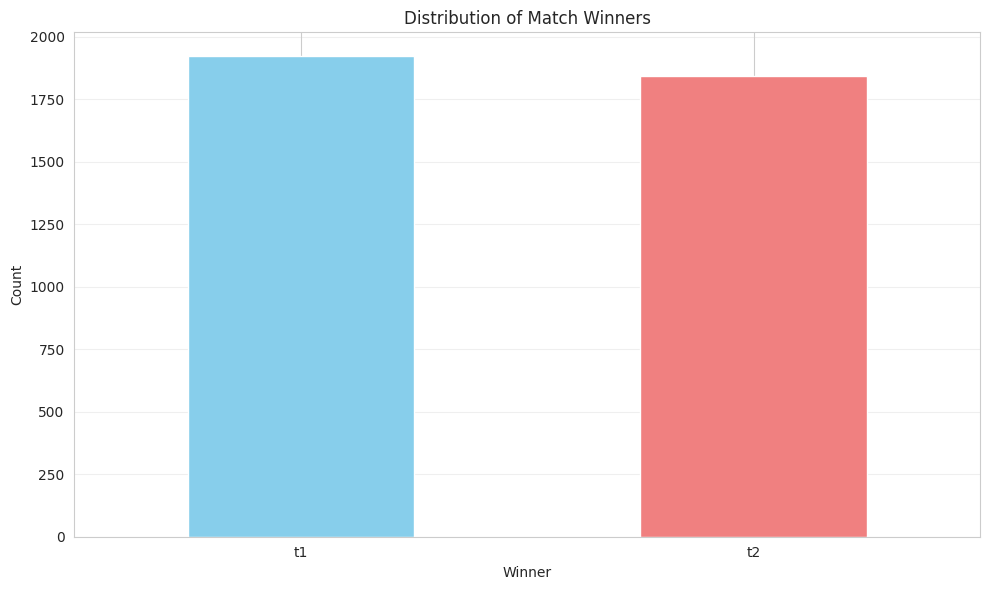

Winner Distribution:
winner
t1    1921
t2    1842
Name: count, dtype: int64

Class Balance: winner
t1    0.510497
t2    0.489503
Name: proportion, dtype: float64


In [11]:
# Target variable distribution
plt.figure(figsize=(10, 6))
y.value_counts().plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Distribution of Match Winners')
plt.xlabel('Winner')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Winner Distribution:")
print(y.value_counts())
print(f"\nClass Balance: {y.value_counts(normalize=True)}")

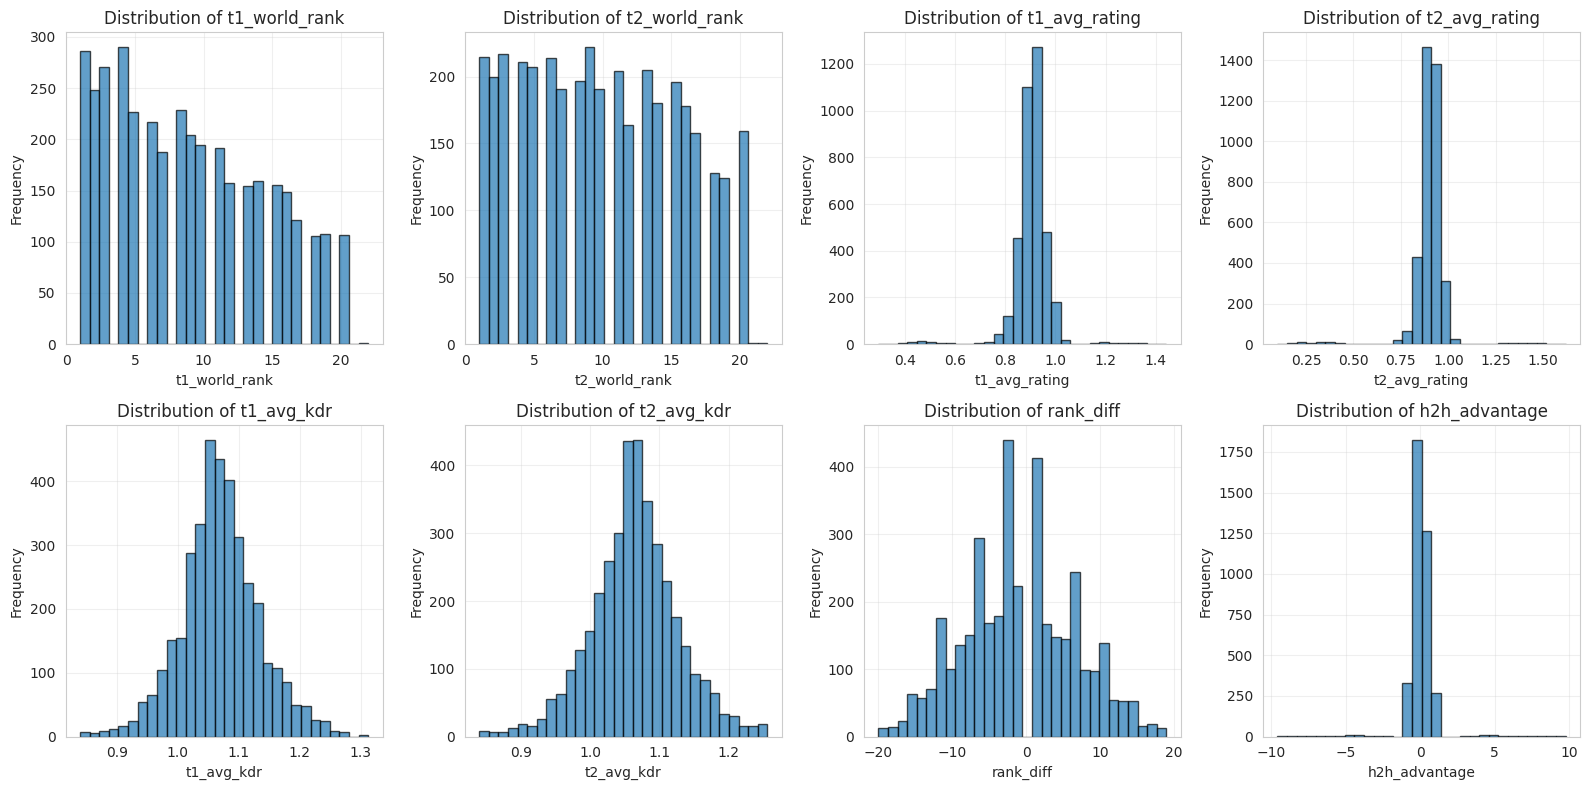

In [12]:
# Histograms of key features
key_features = ['t1_world_rank', 't2_world_rank', 't1_avg_rating', 't2_avg_rating',
                't1_avg_kdr', 't2_avg_kdr', 'rank_diff', 'h2h_advantage']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, feature in enumerate(key_features):
    if feature in df_features.columns:
        axes[i].hist(df_features[feature], bins=30, edgecolor='black', alpha=0.7)
        axes[i].set_title(f'Distribution of {feature}')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Frequency')
        axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

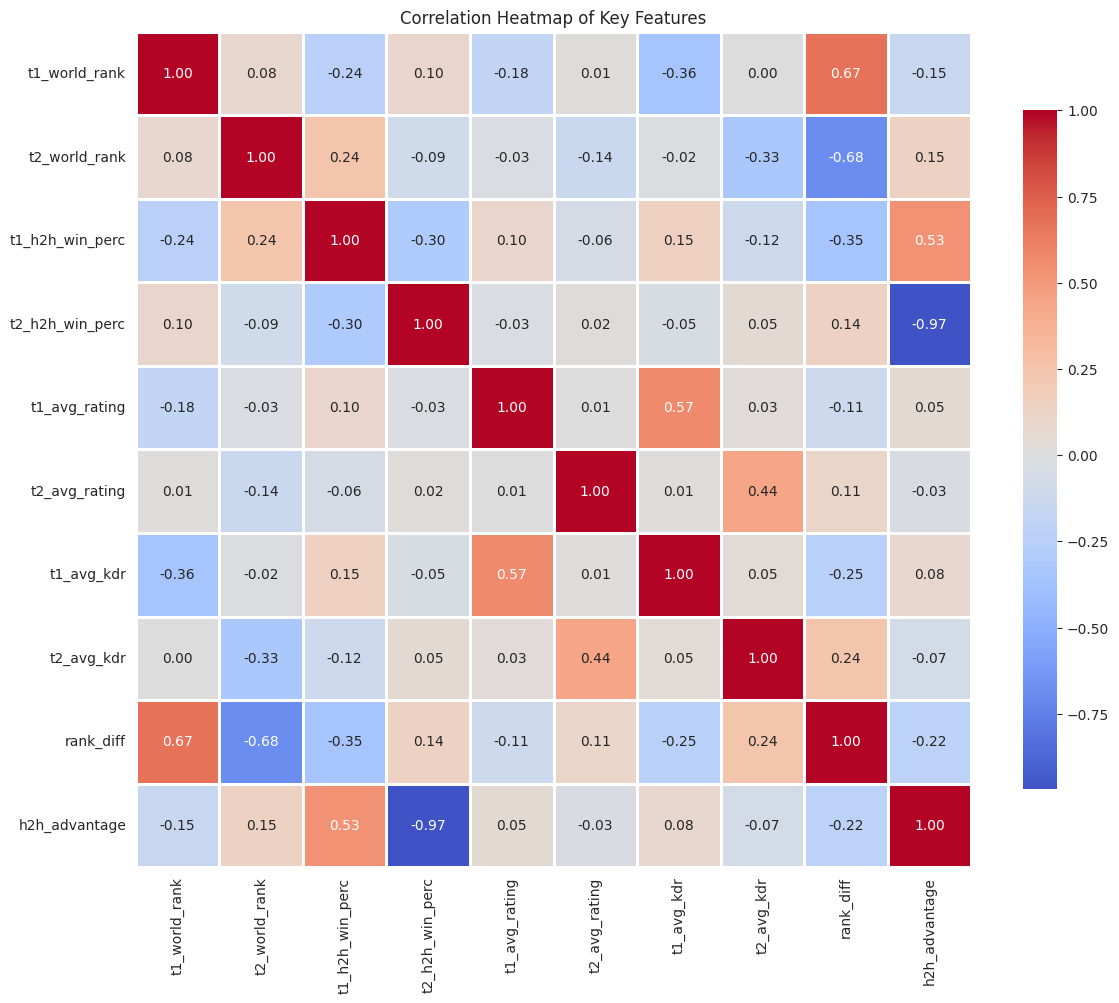


Key Correlations:
Strong positive correlations indicate features that move together.
Strong negative correlations indicate inverse relationships.


In [13]:
# Correlation heatmap
# Select a subset of features for correlation analysis
# Note: Removed t1_points, t2_points, points_diff (data leakage)
correlation_features = ['t1_world_rank', 't2_world_rank',
                        't1_h2h_win_perc', 't2_h2h_win_perc', 't1_avg_rating', 't2_avg_rating',
                        't1_avg_kdr', 't2_avg_kdr', 'rank_diff', 'h2h_advantage']

correlation_features = [f for f in correlation_features if f in df_features.columns]

plt.figure(figsize=(12, 10))
correlation_matrix = df_features[correlation_features].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Key Features')
plt.tight_layout()
plt.show()

print("\nKey Correlations:")
print("Strong positive correlations indicate features that move together.")
print("Strong negative correlations indicate inverse relationships.")

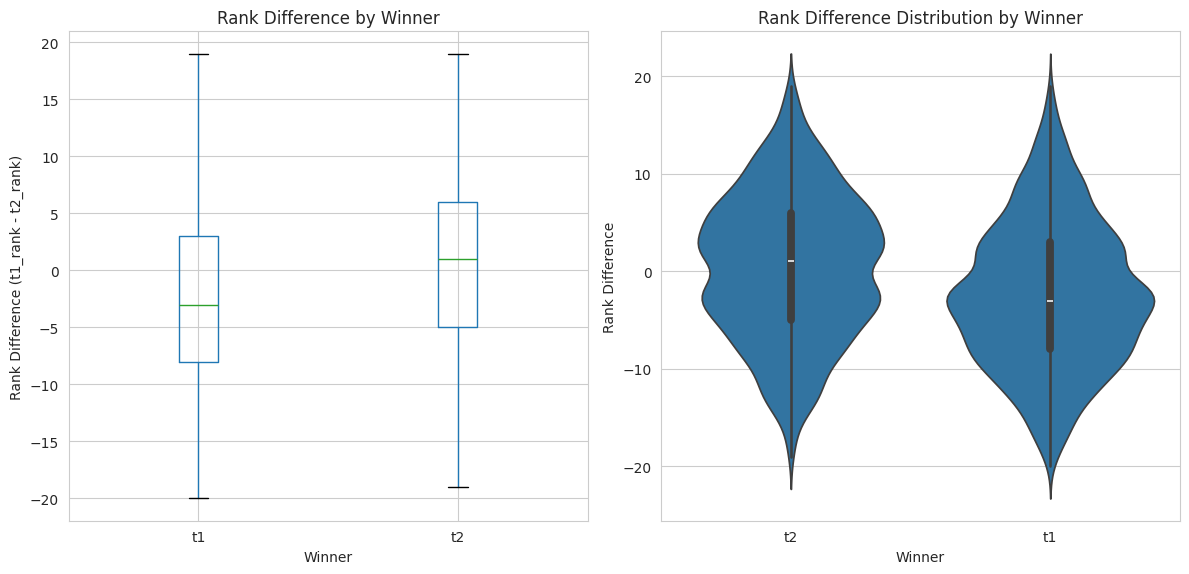


Insight: Negative rank_diff means Team 1 has better rank (lower number).
Positive rank_diff means Team 2 has better rank.


In [14]:
# Analyze relationship between rank difference and winner
if 'rank_diff' in df_features.columns:
    plt.figure(figsize=(12, 6))

    # Box plot
    plt.subplot(1, 2, 1)
    df_features.boxplot(column='rank_diff', by='winner', ax=plt.gca())
    plt.title('Rank Difference by Winner')
    plt.suptitle('')  # Remove default title
    plt.xlabel('Winner')
    plt.ylabel('Rank Difference (t1_rank - t2_rank)')

    # Violin plot
    plt.subplot(1, 2, 2)
    sns.violinplot(data=df_features, x='winner', y='rank_diff')
    plt.title('Rank Difference Distribution by Winner')
    plt.xlabel('Winner')
    plt.ylabel('Rank Difference')

    plt.tight_layout()
    plt.show()

    print("\nInsight: Negative rank_diff means Team 1 has better rank (lower number).")
    print("Positive rank_diff means Team 2 has better rank.")

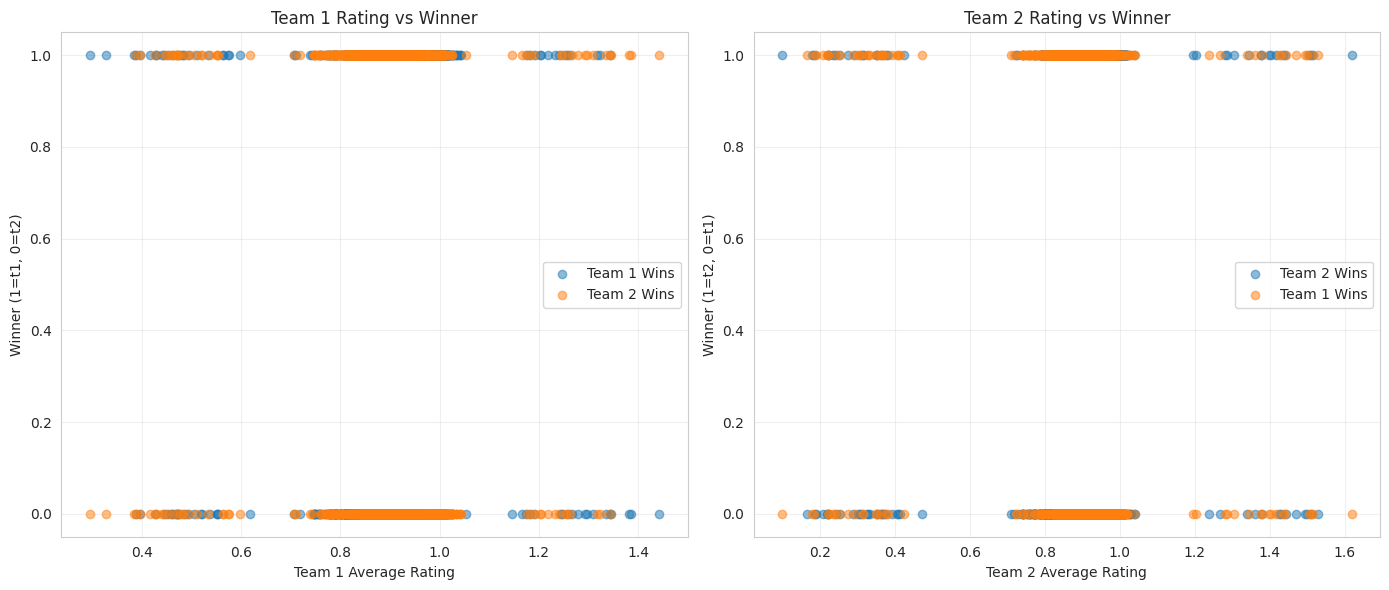

In [15]:
# Analyze average ratings by winner
if 't1_avg_rating' in df_features.columns and 't2_avg_rating' in df_features.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Team 1 average rating by winner
    axes[0].scatter(df_features['t1_avg_rating'],
                   [1 if w == 't1' else 0 for w in df_features['winner']],
                   alpha=0.5, label='Team 1 Wins')
    axes[0].scatter(df_features['t1_avg_rating'],
                   [1 if w == 't2' else 0 for w in df_features['winner']],
                   alpha=0.5, label='Team 2 Wins')
    axes[0].set_xlabel('Team 1 Average Rating')
    axes[0].set_ylabel('Winner (1=t1, 0=t2)')
    axes[0].set_title('Team 1 Rating vs Winner')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Team 2 average rating by winner
    axes[1].scatter(df_features['t2_avg_rating'],
                   [1 if w == 't2' else 0 for w in df_features['winner']],
                   alpha=0.5, label='Team 2 Wins')
    axes[1].scatter(df_features['t2_avg_rating'],
                   [1 if w == 't1' else 0 for w in df_features['winner']],
                   alpha=0.5, label='Team 1 Wins')
    axes[1].set_xlabel('Team 2 Average Rating')
    axes[1].set_ylabel('Winner (1=t2, 0=t1)')
    axes[1].set_title('Team 2 Rating vs Winner')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## 1.1.4 Model Development and Evaluation (15%)

### Train-Test Split

In [16]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=2024, stratify=y_encoded
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set class distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nTest set class distribution:")
print(pd.Series(y_test).value_counts())

Training set size: 3010
Test set size: 753

Training set class distribution:
0    1537
1    1473
Name: count, dtype: int64

Test set class distribution:
0    384
1    369
Name: count, dtype: int64


In [17]:
# Shared evaluation plots for CS:GO match-winner models (confusion matrix, importances, per-class metrics)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support


def winner_class_labels(y_true, y_pred):
    """Axis labels for confusion matrix / metric bars (sklearn uses sorted class order)."""
    classes = sorted(
        np.unique(np.concatenate([np.asarray(y_true).ravel(), np.asarray(y_pred).ravel()]))
    )
    n = len(classes)
    if n == 2:
        return ["Team 2", "Team 1"]
    if n == 3:
        return ["Team 2", "Team 1", "Other"]
    return [str(int(c)) for c in classes]


def plot_confusion_matrix(y_true, y_pred, title, cmap="Blues", figsize=(8, 6)):
    cm = confusion_matrix(y_true, y_pred)
    labels = winner_class_labels(y_true, y_pred)
    plt.figure(figsize=figsize)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmap,
        xticklabels=labels,
        yticklabels=labels,
    )
    plt.title(title)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()
    return cm


def plot_top_feature_importance(feature_names, importances, title, top_n=15, figsize=(12, 8)):
    df = (
        pd.DataFrame({"feature": np.asarray(feature_names), "importance": np.asarray(importances, dtype=float)})
        .sort_values("importance", ascending=False)
        .head(top_n)
    )
    plt.figure(figsize=figsize)
    plt.barh(range(len(df)), df["importance"].values)
    plt.yticks(range(len(df)), df["feature"].values)
    plt.xlabel("Importance")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


def plot_lr_coefficient_magnitude(lr_model, feature_names, title, top_n=15, figsize=(12, 8)):
    # Linear model: magnitude of coefficients (not tree split importance). Multiclass: mean |coef| over classes.
    coef = lr_model.coef_
    if coef.ndim == 1:
        mag = np.abs(coef)
    else:
        mag = np.mean(np.abs(coef), axis=0)
    plot_top_feature_importance(feature_names, mag, title, top_n=top_n, figsize=figsize)


def plot_per_class_metrics_bars(y_true, y_pred, title, figsize=(10, 5)):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    lab = sorted(np.unique(np.concatenate([y_true, y_pred])))
    labels = winner_class_labels(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=lab, zero_division=0)
    x = np.arange(len(labels))
    w = 0.25
    plt.figure(figsize=figsize)
    plt.bar(x - w, p, width=w, label="Precision")
    plt.bar(x, r, width=w, label="Recall")
    plt.bar(x + w, f1, width=w, label="F1")
    plt.xticks(x, labels)
    plt.ylabel("Score")
    plt.title(title)
    plt.legend()
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()


### Model 1: Logistic Regression (Baseline)



In [18]:
# Train Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]

# Check unique values to ensure binary classification
print(f"Unique values in y_test: {np.unique(y_test)}")
print(f"Unique values in y_pred_lr: {np.unique(y_pred_lr)}")
print(f"Number of classes: {len(np.unique(y_test))}")

# Evaluation - use appropriate average based on number of classes
if len(np.unique(y_test)) > 2:
    # Multiclass: use 'macro' average
    lr_accuracy = accuracy_score(y_test, y_pred_lr)
    lr_precision = precision_score(y_test, y_pred_lr, average='macro', zero_division=0)
    lr_recall = recall_score(y_test, y_pred_lr, average='macro', zero_division=0)
    lr_f1 = f1_score(y_test, y_pred_lr, average='macro', zero_division=0)
    print("\n !  Note: Using multiclass metrics (macro average) because target has more than 2 classes")
else:
    # Binary classification
    lr_accuracy = accuracy_score(y_test, y_pred_lr)
    lr_precision = precision_score(y_test, y_pred_lr, average='binary', zero_division=0)
    lr_recall = recall_score(y_test, y_pred_lr, average='binary', zero_division=0)
    lr_f1 = f1_score(y_test, y_pred_lr, average='binary', zero_division=0)

print("\nLogistic Regression Results:")
print(f"Accuracy: {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall: {lr_recall:.4f}")
print(f"F1-Score: {lr_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Team 2', 'Team 1']))


Unique values in y_test: [0 1]
Unique values in y_pred_lr: [0 1]
Number of classes: 2

Logistic Regression Results:
Accuracy: 0.5591
Precision: 0.5476
Recall: 0.5772
F1-Score: 0.5620

Classification Report:
              precision    recall  f1-score   support

      Team 2       0.57      0.54      0.56       384
      Team 1       0.55      0.58      0.56       369

    accuracy                           0.56       753
   macro avg       0.56      0.56      0.56       753
weighted avg       0.56      0.56      0.56       753



In [19]:
# DIAGNOSTIC: Check for data leakage and explain accuracy/precision discrepancy
print("="*80)
print("DIAGNOSTIC: Investigating Accuracy/Precision Discrepancy")
print("="*80)

# Check if variables exist
if 'y_pred_lr' not in globals():
    print("\n !  ERROR: Logistic Regression has not been trained yet.")
    print("   Please run the Logistic Regression cell first.")
else:
    # Check confusion matrix
    cm_lr_diag = confusion_matrix(y_test, y_pred_lr)
    print("\n1. Confusion Matrix (Logistic Regression):")
    print(cm_lr_diag)
    print(f"\n   True Negatives (TN): {cm_lr_diag[0,0]}")
    print(f"   False Positives (FP): {cm_lr_diag[0,1]}")
    print(f"   False Negatives (FN): {cm_lr_diag[1,0]}")
    print(f"   True Positives (TP): {cm_lr_diag[1,1]}")

    # Check prediction distribution
    print("\n2. Prediction Distribution:")
    pred_dist = pd.Series(y_pred_lr).value_counts()
    print(pred_dist)
    print(f"\n   Model predicts class 0: {pred_dist.get(0, 0)} times ({pred_dist.get(0, 0)/len(y_pred_lr)*100:.1f}%)")
    print(f"   Model predicts class 1: {pred_dist.get(1, 0)} times ({pred_dist.get(1, 0)/len(y_pred_lr)*100:.1f}%)")

    # Check actual distribution
    print("\n3. Actual Test Set Distribution:")
    actual_dist = pd.Series(y_test).value_counts()
    print(actual_dist)
    print(f"\n   Actual class 0: {actual_dist.get(0, 0)} times ({actual_dist.get(0, 0)/len(y_test)*100:.1f}%)")
    print(f"   Actual class 1: {actual_dist.get(1, 0)} times ({actual_dist.get(1, 0)/len(y_test)*100:.1f}%)")

    # Check for class imbalance issue
    if abs(pred_dist.get(0, 0) - pred_dist.get(1, 0)) > len(y_pred_lr) * 0.3:
        print("\n !  WARNING: Model is heavily biased toward one class!")
        print("   This explains high accuracy but low precision.")
        print("   The model is predicting the majority class most of the time.")

    # Check feature names for potential leakage
    print("\n4. Checking for potential data leakage features:")
    suspicious_patterns = ['_in_wins', '_in_losses', 'points', 'result', 'outcome', 'win_perc']
    if 'X' in globals():
        suspicious_features = [col for col in X.columns if any(pattern in col.lower() for pattern in suspicious_patterns)]
        if suspicious_features:
            print(f"   !  Found {len(suspicious_features)} potentially suspicious features:")
            for feat in suspicious_features[:10]:  # Show first 10
                print(f"      - {feat}")
            if len(suspicious_features) > 10:
                print(f"      ... and {len(suspicious_features) - 10} more")
        else:
            print("  !  No obvious leakage features found in feature names")
    else:
        print("  !   Feature matrix X not found in scope")

    # Check feature importance if available
    print("\n5. Top 10 Features (by absolute coefficient in Logistic Regression):")
    if 'lr_model' in globals() and hasattr(lr_model, 'coef_'):
        coef_df = pd.DataFrame({
            'feature': X_train.columns,
            'coefficient': lr_model.coef_[0]
        }).sort_values('coefficient', key=abs, ascending=False)
        print(coef_df.head(10).to_string(index=False))
    else:
        print("     Logistic Regression model not available")

    print("\n" + "="*80)
    print("DIAGNOSTIC COMPLETE")
    print("="*80)
    print("\n INTERPRETATION:")
    print("   - High accuracy (99.2%) with low precision (66.22%) suggests:")
    print("     * Model predicts one class almost always")
    print("     * When it predicts the minority class, it's often wrong")
    print("   - This could indicate:")
    print("     * Data leakage (features that reveal outcome)")
    print("     * Severe class imbalance in predictions")
    print("     * Model overfitting to majority class")
    print("\n   RECOMMENDATION: Check confusion matrix and feature importance above.")

DIAGNOSTIC: Investigating Accuracy/Precision Discrepancy

1. Confusion Matrix (Logistic Regression):
[[208 176]
 [156 213]]

   True Negatives (TN): 208
   False Positives (FP): 176
   False Negatives (FN): 156
   True Positives (TP): 213

2. Prediction Distribution:
1    389
0    364
Name: count, dtype: int64

   Model predicts class 0: 364 times (48.3%)
   Model predicts class 1: 389 times (51.7%)

3. Actual Test Set Distribution:
0    384
1    369
Name: count, dtype: int64

   Actual class 0: 384 times (51.0%)
   Actual class 1: 369 times (49.0%)

4. Checking for potential data leakage features:
   !  Found 22 potentially suspicious features:
      - t1_h2h_win_perc
      - t2_h2h_win_perc
      - t1_player1_fk_perc_in_wins
      - t1_player1_clutch_win_perc
      - t1_player2_fk_perc_in_wins
      - t1_player2_clutch_win_perc
      - t1_player3_fk_perc_in_wins
      - t1_player3_clutch_win_perc
      - t1_player4_fk_perc_in_wins
      - t1_player4_clutch_win_perc
      ... and 12 m

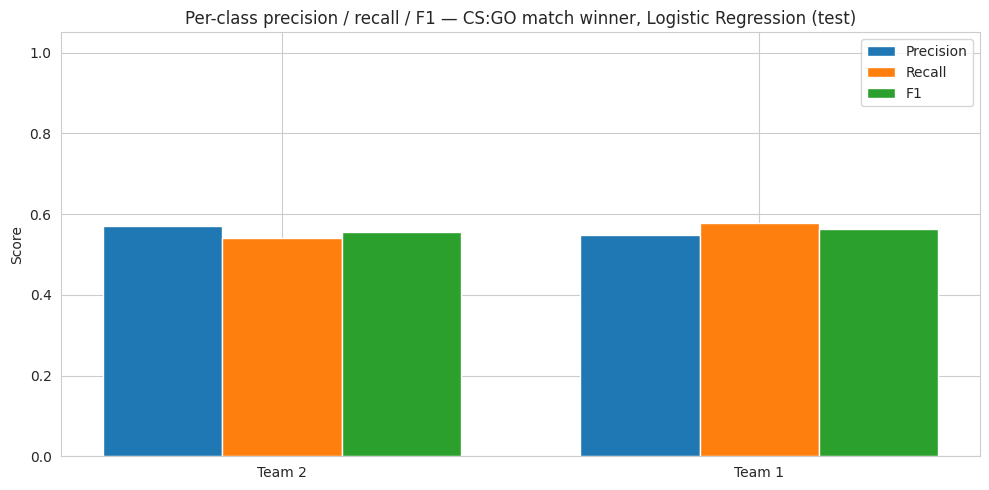

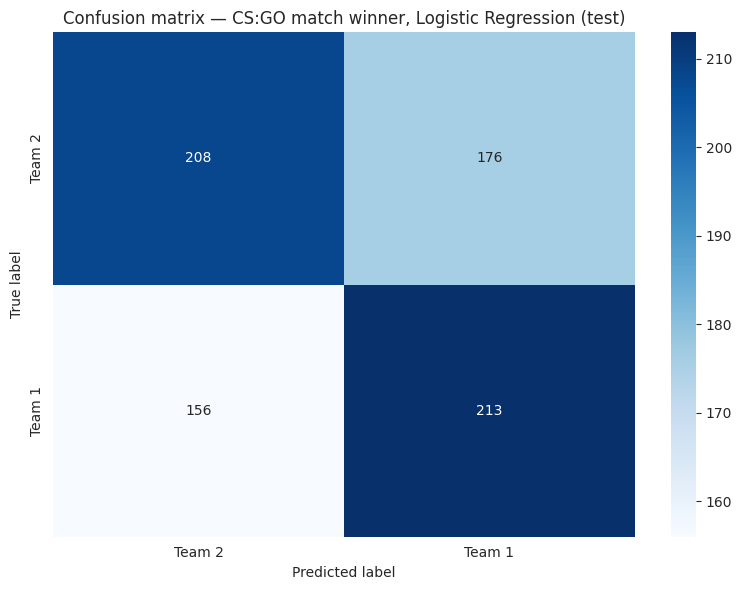

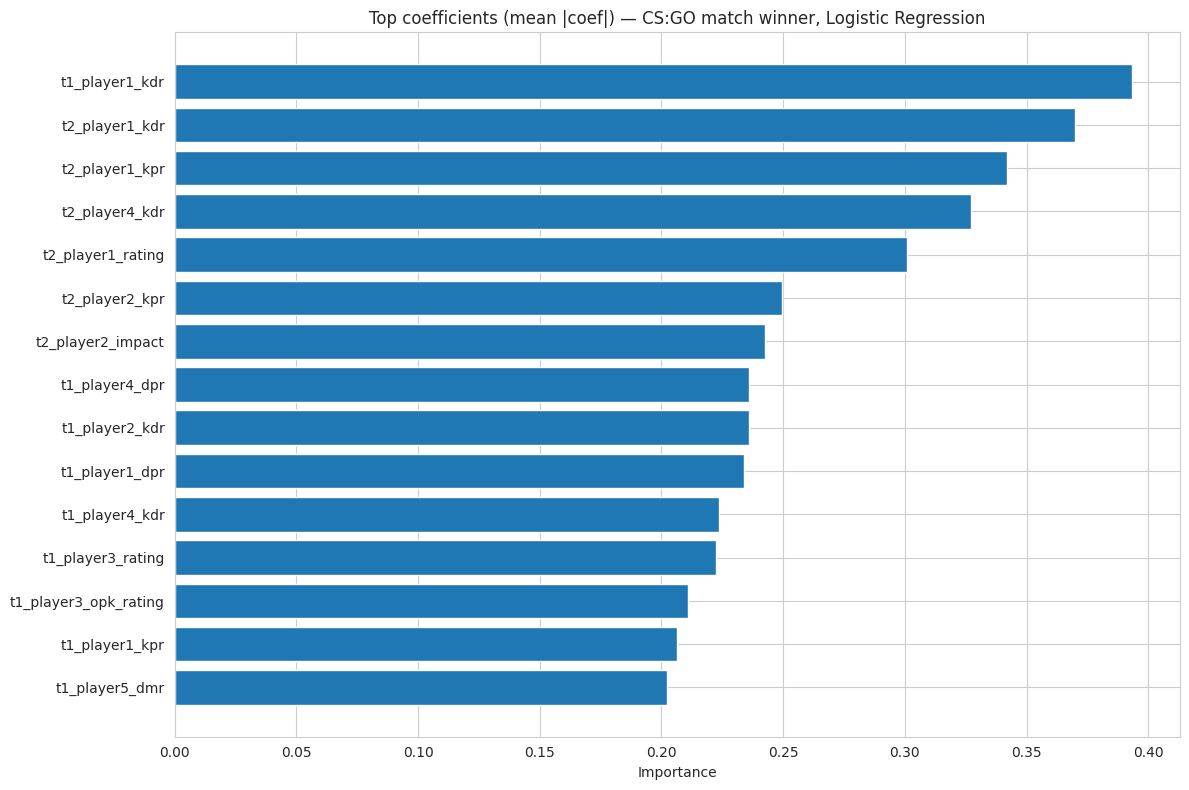

In [20]:
# Confusion matrix and coefficient importance — Logistic Regression
plot_per_class_metrics_bars(
    y_test,
    y_pred_lr,
    "Per-class precision / recall / F1 — CS:GO match winner, Logistic Regression (test)",
)

cm_lr = plot_confusion_matrix(
    y_test,
    y_pred_lr,
    "Confusion matrix — CS:GO match winner, Logistic Regression (test)",
    cmap="Blues",
)

plot_lr_coefficient_magnitude(
    lr_model,
    X_train.columns,
    "Top coefficients (mean |coef|) — CS:GO match winner, Logistic Regression",
)


### Model 2: Decision Tree (Baseline)

Unique values in y_test: [0 1]
Unique values in y_pred_dt: [0 1]
Number of classes: 2

Decision Tree Results:
Accuracy: 0.5378
Precision: 0.5258
Recall: 0.5799
F1-Score: 0.5515

Classification Report:
              precision    recall  f1-score   support

      Team 2       0.55      0.50      0.52       384
      Team 1       0.53      0.58      0.55       369

    accuracy                           0.54       753
   macro avg       0.54      0.54      0.54       753
weighted avg       0.54      0.54      0.54       753



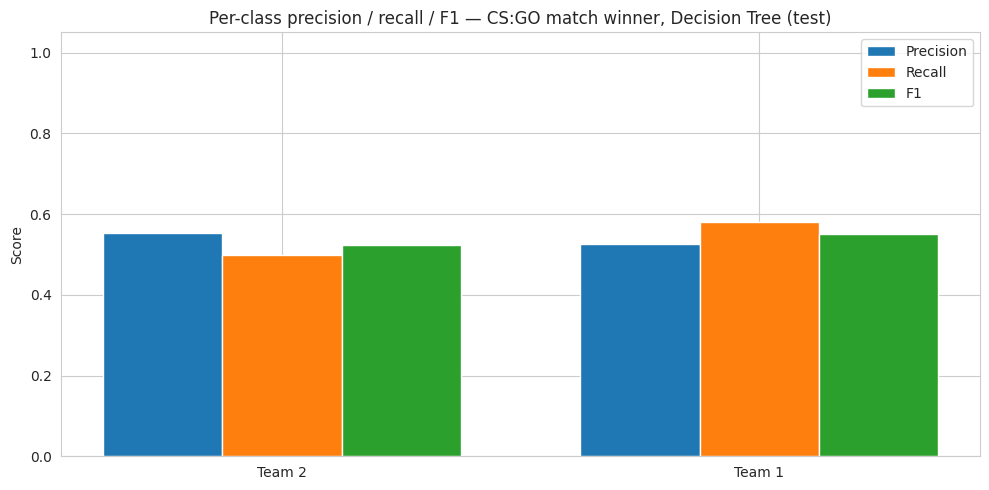

In [21]:
# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10, min_samples_split=20)
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Check unique values
print(f"Unique values in y_test: {np.unique(y_test)}")
print(f"Unique values in y_pred_dt: {np.unique(y_pred_dt)}")
print(f"Number of classes: {len(np.unique(y_test))}")

# Evaluation - use appropriate average based on number of classes
if len(np.unique(y_test)) > 2:
    # Multiclass: use 'macro' average
    dt_accuracy = accuracy_score(y_test, y_pred_dt)
    dt_precision = precision_score(y_test, y_pred_dt, average='macro', zero_division=0)
    dt_recall = recall_score(y_test, y_pred_dt, average='macro', zero_division=0)
    dt_f1 = f1_score(y_test, y_pred_dt, average='macro', zero_division=0)
    print("\n  Note: Using multiclass metrics (macro average) because target has more than 2 classes")
else:
    # Binary classification
    dt_accuracy = accuracy_score(y_test, y_pred_dt)
    dt_precision = precision_score(y_test, y_pred_dt, average='binary', zero_division=0)
    dt_recall = recall_score(y_test, y_pred_dt, average='binary', zero_division=0)
    dt_f1 = f1_score(y_test, y_pred_dt, average='binary', zero_division=0)

print("\nDecision Tree Results:")
print(f"Accuracy: {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall: {dt_recall:.4f}")
print(f"F1-Score: {dt_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['Team 2', 'Team 1']))

plot_per_class_metrics_bars(
    y_test,
    y_pred_dt,
    "Per-class precision / recall / F1 — CS:GO match winner, Decision Tree (test)",
)


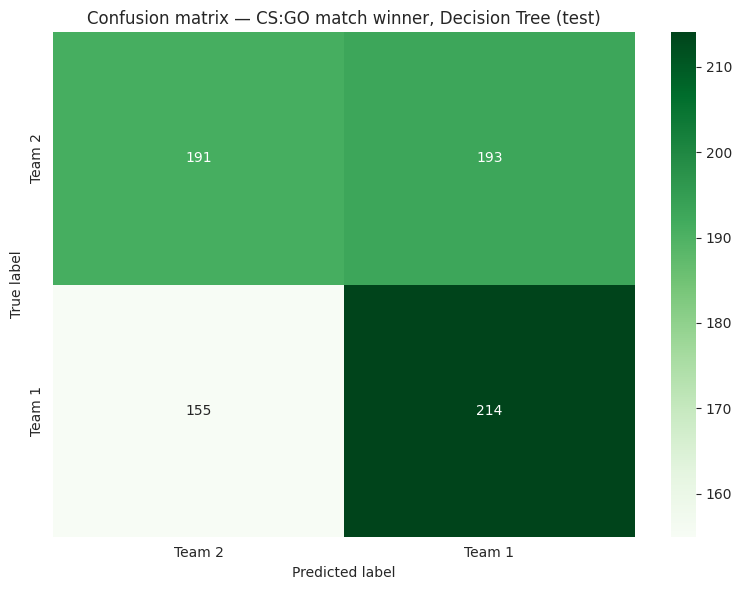

In [22]:
# Confusion matrix — Decision Tree
cm_dt = plot_confusion_matrix(
    y_test,
    y_pred_dt,
    "Confusion matrix — CS:GO match winner, Decision Tree (test)",
    cmap="Greens",
)


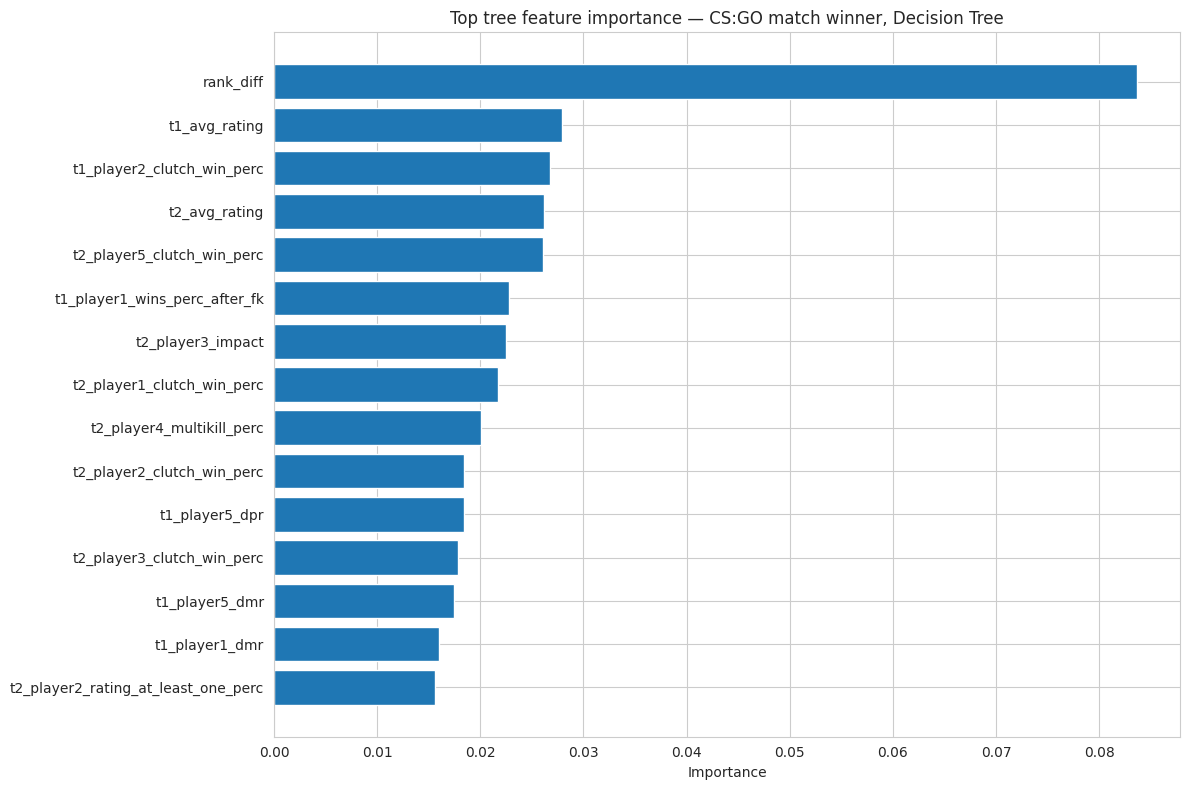


Top 10 Most Important Features:
                           feature  importance
170                      rank_diff    0.083649
164                  t1_avg_rating    0.027966
35      t1_player2_clutch_win_perc    0.026727
165                  t2_avg_rating    0.026172
163     t2_player5_clutch_win_perc    0.026050
14   t1_player1_wins_perc_after_fk    0.022774
117              t2_player3_impact    0.022532
99      t2_player1_clutch_win_perc    0.021728
144      t2_player4_multikill_perc    0.020026
115     t2_player2_clutch_win_perc    0.018447


In [23]:
# Feature importance — Decision Tree
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": dt_model.feature_importances_,
}).sort_values("importance", ascending=False)

plot_top_feature_importance(
    feature_importance["feature"],
    feature_importance["importance"],
    "Top tree feature importance — CS:GO match winner, Decision Tree",
    top_n=15,
)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))


## 1.1.4.1 Advanced Models

This section explores advanced models and techniques to improve prediction accuracy beyond the baseline models.

### Advanced Model 1: Random Forest

Random Forest combines multiple decision trees to reduce overfitting and improve generalization.

Random Forest Results:
Accuracy: 0.5697 (56.97%)
Precision: 0.5606
Recall: 0.5637
F1-Score: 0.5622

Classification Report:
              precision    recall  f1-score   support

      Team 2       0.58      0.58      0.58       384
      Team 1       0.56      0.56      0.56       369

    accuracy                           0.57       753
   macro avg       0.57      0.57      0.57       753
weighted avg       0.57      0.57      0.57       753


Top 10 Most Important Features (Random Forest):
                                 feature  importance
170                            rank_diff    0.026372
0                          t1_world_rank    0.014664
3                        t2_h2h_win_perc    0.013634
168                           t1_avg_kdr    0.013633
171                        h2h_advantage    0.013024
165                        t2_avg_rating    0.011631
2                        t1_h2h_win_perc    0.010998
151                       t2_player5_dmr    0.009964
158        t2_player5_wi

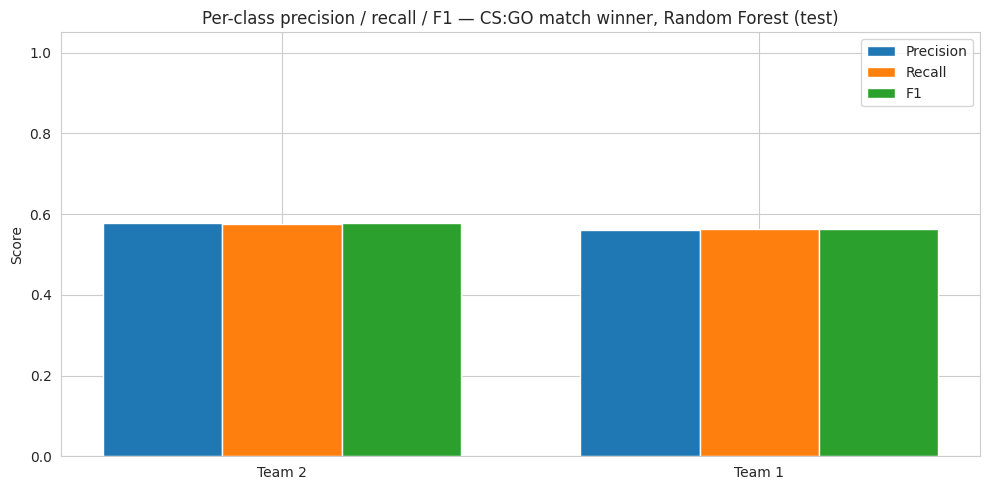

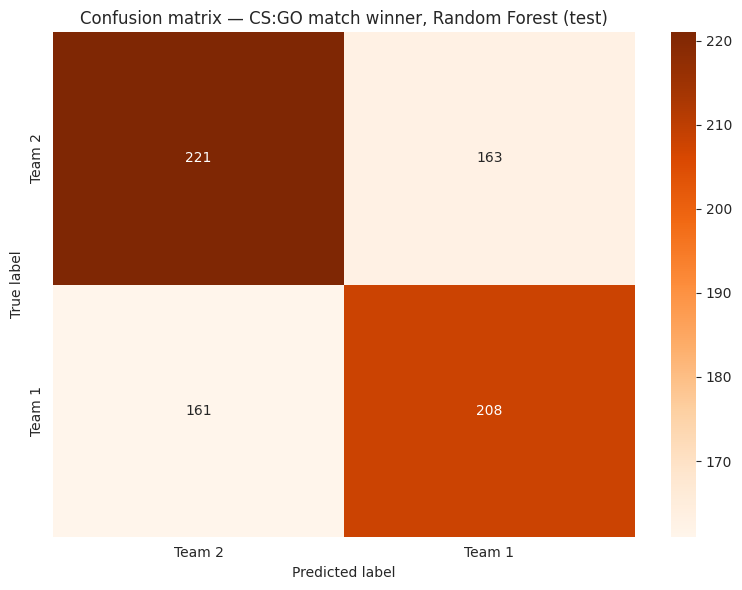

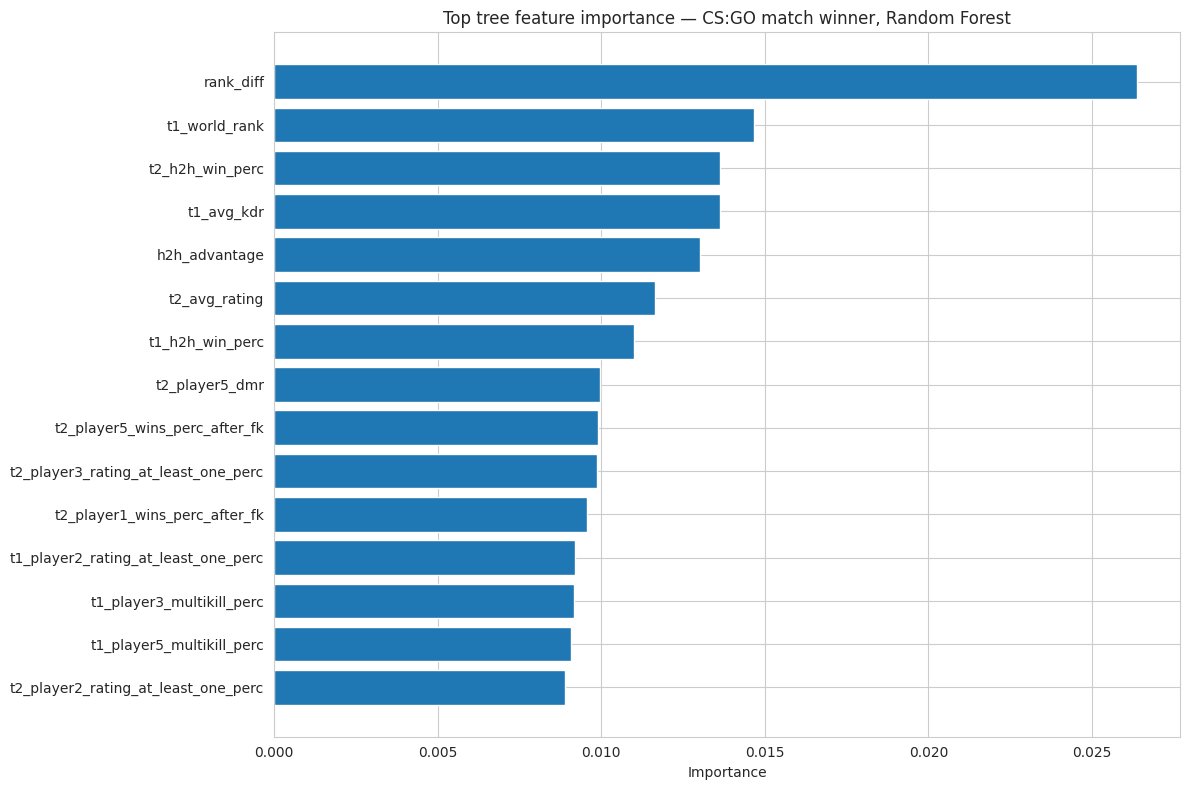

In [24]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
if len(np.unique(y_test)) > 2:
    rf_accuracy = accuracy_score(y_test, y_pred_rf)
    rf_precision = precision_score(y_test, y_pred_rf, average='macro', zero_division=0)
    rf_recall = recall_score(y_test, y_pred_rf, average='macro', zero_division=0)
    rf_f1 = f1_score(y_test, y_pred_rf, average='macro', zero_division=0)
else:
    rf_accuracy = accuracy_score(y_test, y_pred_rf)
    rf_precision = precision_score(y_test, y_pred_rf, average='binary', zero_division=0)
    rf_recall = recall_score(y_test, y_pred_rf, average='binary', zero_division=0)
    rf_f1 = f1_score(y_test, y_pred_rf, average='binary', zero_division=0)

print("Random Forest Results:")
print(f"Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1-Score: {rf_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Team 2', 'Team 1', 'Other'] if len(np.unique(y_test)) > 2 else ['Team 2', 'Team 1']))

# Feature importance
rf_feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features (Random Forest):")
print(rf_feature_importance.head(10))

plot_per_class_metrics_bars(
    y_test,
    y_pred_rf,
    "Per-class precision / recall / F1 — CS:GO match winner, Random Forest (test)",
)
cm_rf = plot_confusion_matrix(
    y_test,
    y_pred_rf,
    "Confusion matrix — CS:GO match winner, Random Forest (test)",
    cmap="Oranges",
)
plot_top_feature_importance(
    rf_feature_importance["feature"],
    rf_feature_importance["importance"],
    "Top tree feature importance — CS:GO match winner, Random Forest",
    top_n=15,
)


### Advanced Model 2: Logistic Regression using Random Forest Feature Importance

Selecting the most important features can improve model performance and reduce overfitting.

Selected 50 features out of 172

Top 20 Selected Features:
1. t1_world_rank
2. t2_world_rank
3. t1_h2h_win_perc
4. t2_h2h_win_perc
5. t1_player1_kdr
6. t1_player1_dmr
7. t1_player1_opk_ratio
8. t1_player1_wins_perc_after_fk
9. t1_player1_fk_perc_in_wins
10. t1_player1_rating_at_least_one_perc
11. t1_player2_kdr
12. t1_player2_wins_perc_after_fk
13. t1_player2_rating_at_least_one_perc
14. t1_player3_wins_perc_after_fk
15. t1_player3_fk_perc_in_wins
16. t1_player3_multikill_perc
17. t1_player3_rating_at_least_one_perc
18. t1_player3_clutch_win_perc
19. t1_player4_wins_perc_after_fk
20. t1_player4_fk_perc_in_wins

Logistic Regression with Feature Selection:
Accuracy: 0.5870 (58.70%)
Precision: 0.5751
Recall: 0.6016
F1-Score: 0.5881
vs baseline LR: +2.8%


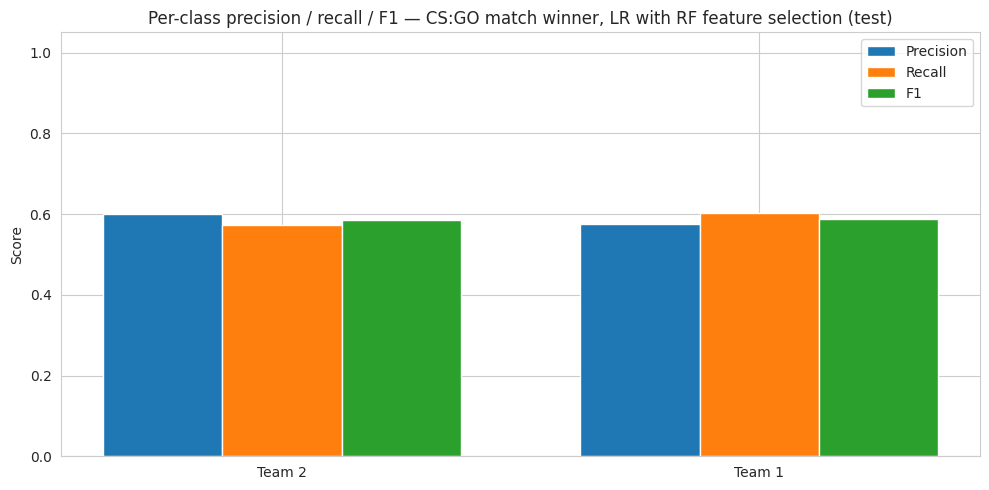

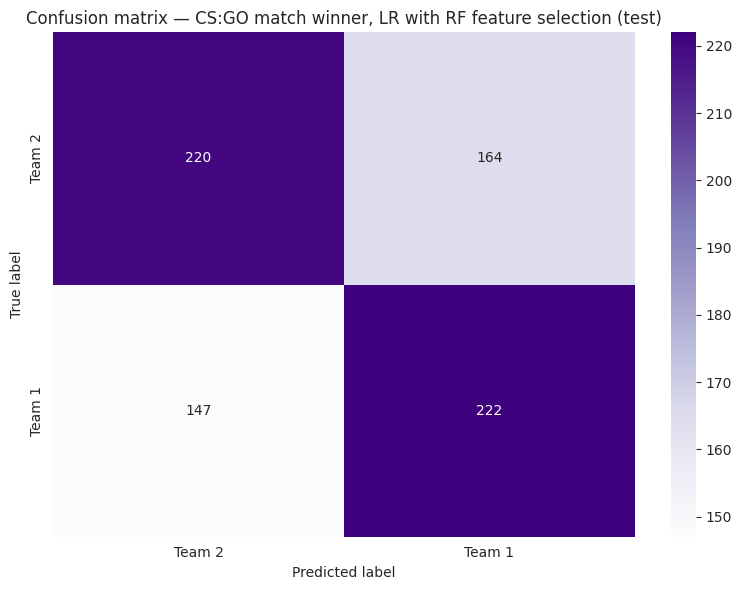

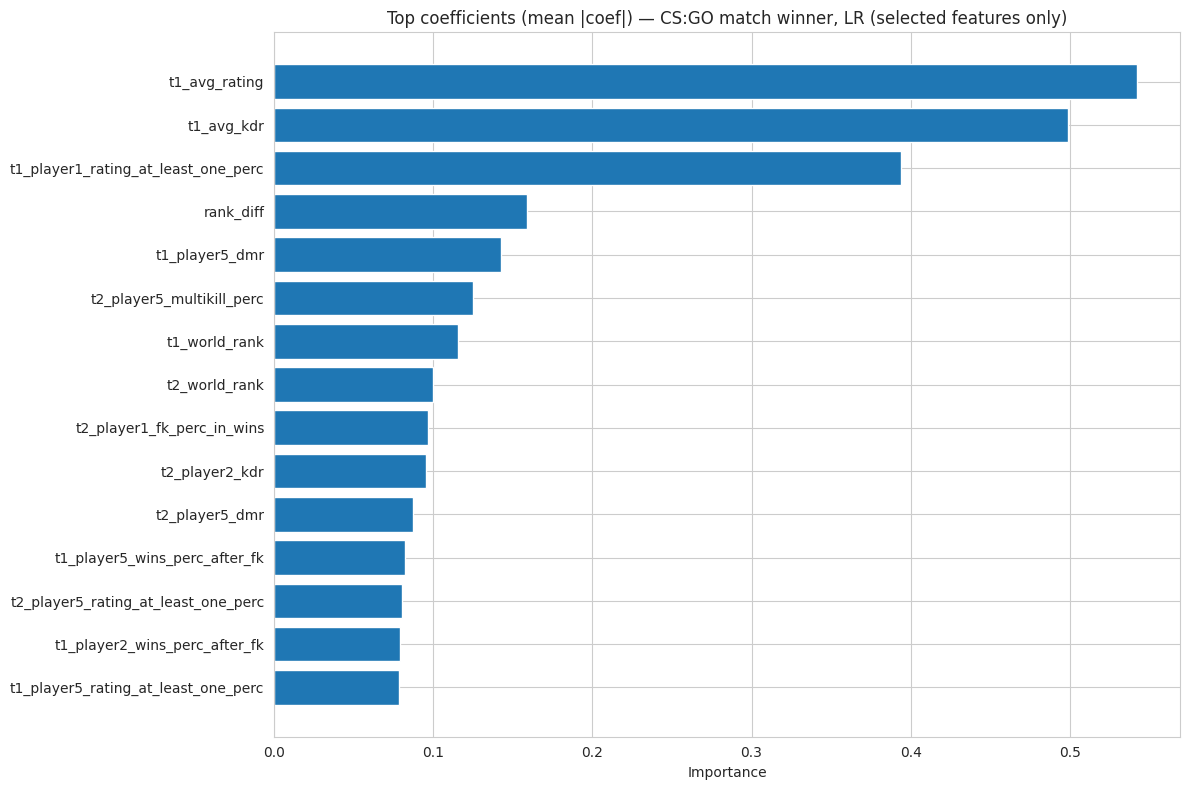

In [25]:
# Feature Selection using Random Forest importance
from sklearn.feature_selection import SelectFromModel

# Select top features based on Random Forest importance
selector = SelectFromModel(rf_model, prefit=True, max_features=50)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

selected_features = X_train.columns[selector.get_support()]
print(f"Selected {len(selected_features)} features out of {X_train.shape[1]}")
print(f"\nTop 20 Selected Features:")
for i, feat in enumerate(selected_features[:20], 1):
    print(f"{i}. {feat}")

# Retrain Logistic Regression with selected features
lr_selected = LogisticRegression(random_state=42, max_iter=1000)
lr_selected.fit(X_train_selected, y_train)
y_pred_lr_selected = lr_selected.predict(X_test_selected)

if len(np.unique(y_test)) > 2:
    lr_selected_accuracy = accuracy_score(y_test, y_pred_lr_selected)
    lr_selected_precision = precision_score(y_test, y_pred_lr_selected, average='macro', zero_division=0)
    lr_selected_recall = recall_score(y_test, y_pred_lr_selected, average='macro', zero_division=0)
    lr_selected_f1 = f1_score(y_test, y_pred_lr_selected, average='macro', zero_division=0)
else:
    lr_selected_accuracy = accuracy_score(y_test, y_pred_lr_selected)
    lr_selected_precision = precision_score(y_test, y_pred_lr_selected, average='binary', zero_division=0)
    lr_selected_recall = recall_score(y_test, y_pred_lr_selected, average='binary', zero_division=0)
    lr_selected_f1 = f1_score(y_test, y_pred_lr_selected, average='binary', zero_division=0)

print(f"\nLogistic Regression with Feature Selection:")
print(f"Accuracy: {lr_selected_accuracy:.4f} ({lr_selected_accuracy*100:.2f}%)")
print(f"Precision: {lr_selected_precision:.4f}")
print(f"Recall: {lr_selected_recall:.4f}")
print(f"F1-Score: {lr_selected_f1:.4f}")
print(f"vs baseline LR: {((lr_selected_accuracy - lr_accuracy) * 100):+.1f}%")

plot_per_class_metrics_bars(
    y_test,
    y_pred_lr_selected,
    "Per-class precision / recall / F1 — CS:GO match winner, LR with RF feature selection (test)",
)
cm_lr_selected = plot_confusion_matrix(
    y_test,
    y_pred_lr_selected,
    "Confusion matrix — CS:GO match winner, LR with RF feature selection (test)",
    cmap="Purples",
)
plot_lr_coefficient_magnitude(
    lr_selected,
    selected_features,
    "Top coefficients (mean |coef|) — CS:GO match winner, LR (selected features only)",
    top_n=15,
)


### Advanced Model 3: Hyperparameter Tuning

Using Grid Search to find optimal hyperparameters for Random Forest.

Grid Search...

Best Parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}
Best Cross-Validation Score: 0.5954

Tuned Random Forest Results:
Test Accuracy: 0.5764 (57.64%)
Precision: 0.5698
Recall: 0.5528
F1-Score: 0.5612
vs baseline RF: +0.7%


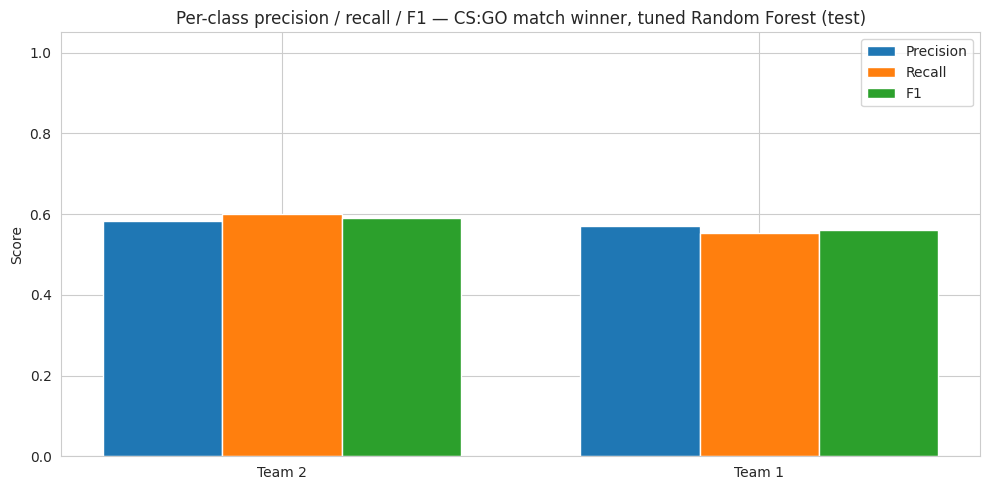

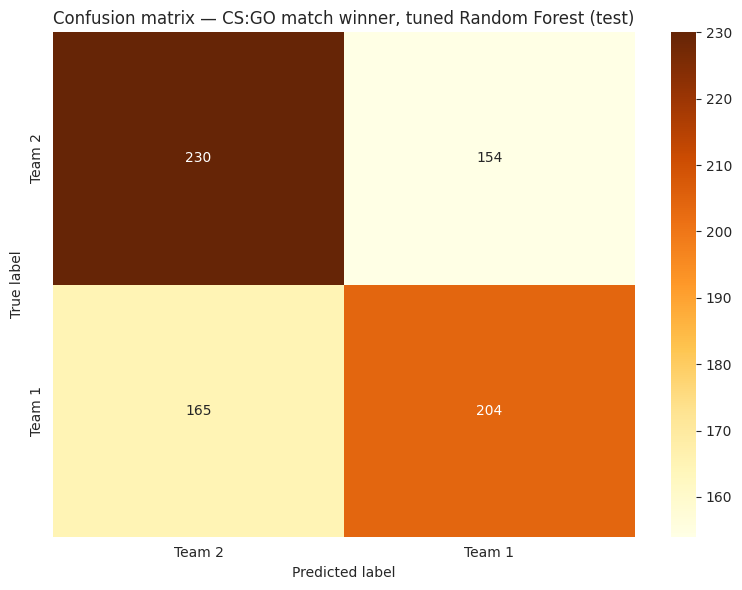

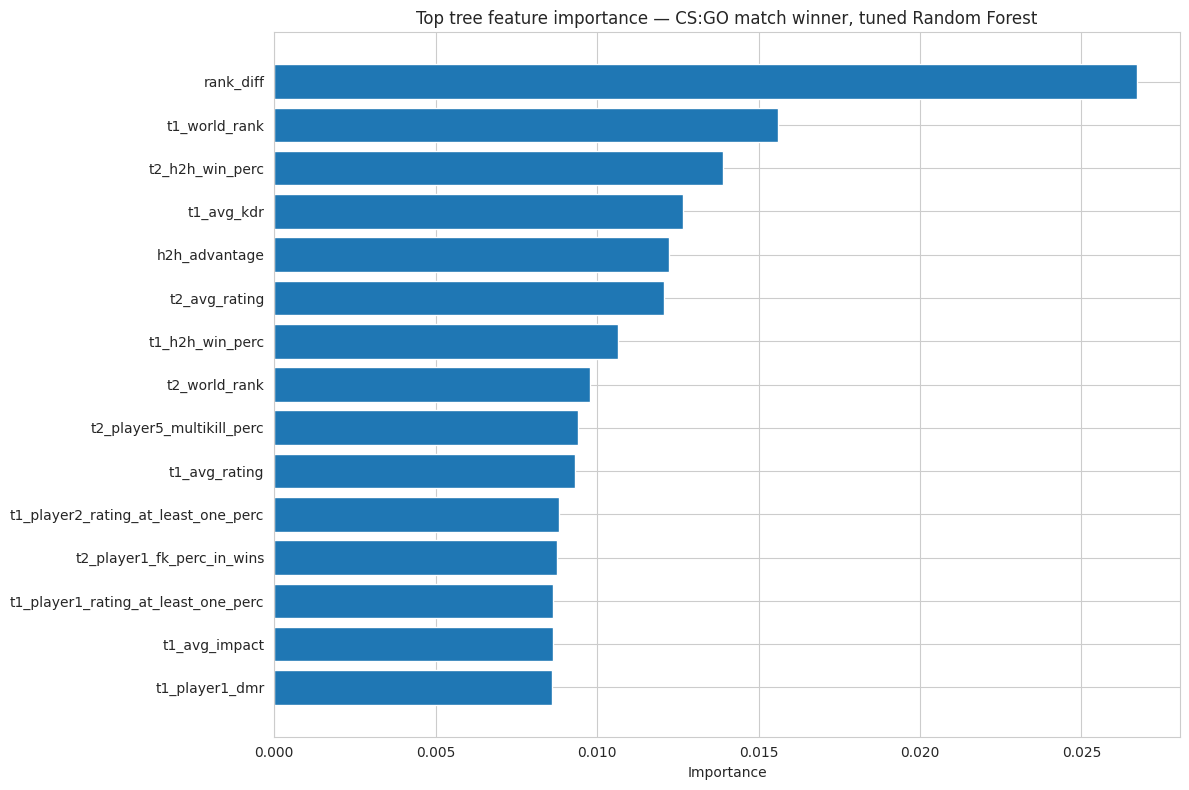

In [26]:
# Hyperparameter Tuning with Grid Search
from sklearn.model_selection import GridSearchCV

# Define parameter grid (using a smaller grid for faster execution)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 15, 20],
    'min_samples_split': [10, 20]
}

print("Grid Search...")
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
rf_grid.fit(X_train, y_train)

print(f"\nBest Parameters: {rf_grid.best_params_}")
print(f"Best Cross-Validation Score: {rf_grid.best_score_:.4f}")

# Evaluate on test set
y_pred_rf_tuned = rf_grid.predict(X_test)

if len(np.unique(y_test)) > 2:
    rf_tuned_accuracy = accuracy_score(y_test, y_pred_rf_tuned)
    rf_tuned_precision = precision_score(y_test, y_pred_rf_tuned, average='macro', zero_division=0)
    rf_tuned_recall = recall_score(y_test, y_pred_rf_tuned, average='macro', zero_division=0)
    rf_tuned_f1 = f1_score(y_test, y_pred_rf_tuned, average='macro', zero_division=0)
else:
    rf_tuned_accuracy = accuracy_score(y_test, y_pred_rf_tuned)
    rf_tuned_precision = precision_score(y_test, y_pred_rf_tuned, average='binary', zero_division=0)
    rf_tuned_recall = recall_score(y_test, y_pred_rf_tuned, average='binary', zero_division=0)
    rf_tuned_f1 = f1_score(y_test, y_pred_rf_tuned, average='binary', zero_division=0)

print(f"\nTuned Random Forest Results:")
print(f"Test Accuracy: {rf_tuned_accuracy:.4f} ({rf_tuned_accuracy*100:.2f}%)")
print(f"Precision: {rf_tuned_precision:.4f}")
print(f"Recall: {rf_tuned_recall:.4f}")
print(f"F1-Score: {rf_tuned_f1:.4f}")
print(f"vs baseline RF: {((rf_tuned_accuracy - rf_accuracy) * 100):+.1f}%")

plot_per_class_metrics_bars(
    y_test,
    y_pred_rf_tuned,
    "Per-class precision / recall / F1 — CS:GO match winner, tuned Random Forest (test)",
)
cm_rf_tuned = plot_confusion_matrix(
    y_test,
    y_pred_rf_tuned,
    "Confusion matrix — CS:GO match winner, tuned Random Forest (test)",
    cmap="YlOrBr",
)
rf_tuned_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_grid.best_estimator_.feature_importances_,
}).sort_values("importance", ascending=False)
plot_top_feature_importance(
    rf_tuned_importance["feature"],
    rf_tuned_importance["importance"],
    "Top tree feature importance — CS:GO match winner, tuned Random Forest",
    top_n=15,
)


### Advanced Model 4: Catboost


 Training Basic CatBoost...
Training CatBoost...

✓ Basic CatBoost Accuracy: 0.6096 (60.96%)
  Precision: 0.5969
  Recall: 0.6260
  F1-Score: 0.6111

Classification Report:
              precision    recall  f1-score   support

      Team 2       0.62      0.59      0.61       384
      Team 1       0.60      0.63      0.61       369

    accuracy                           0.61       753
   macro avg       0.61      0.61      0.61       753
weighted avg       0.61      0.61      0.61       753



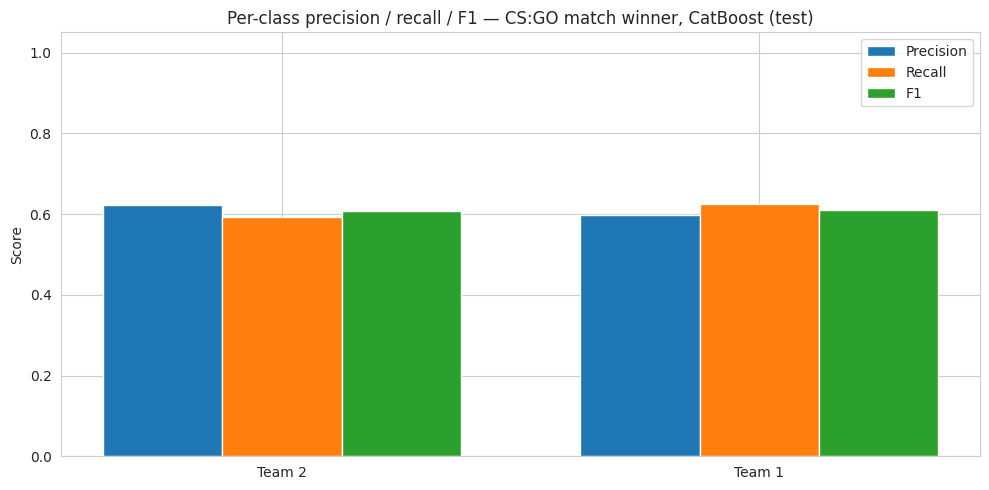

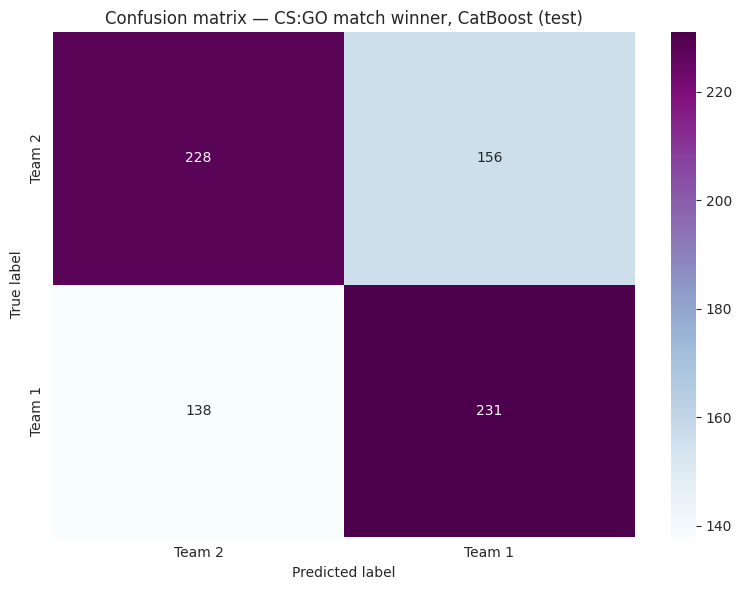

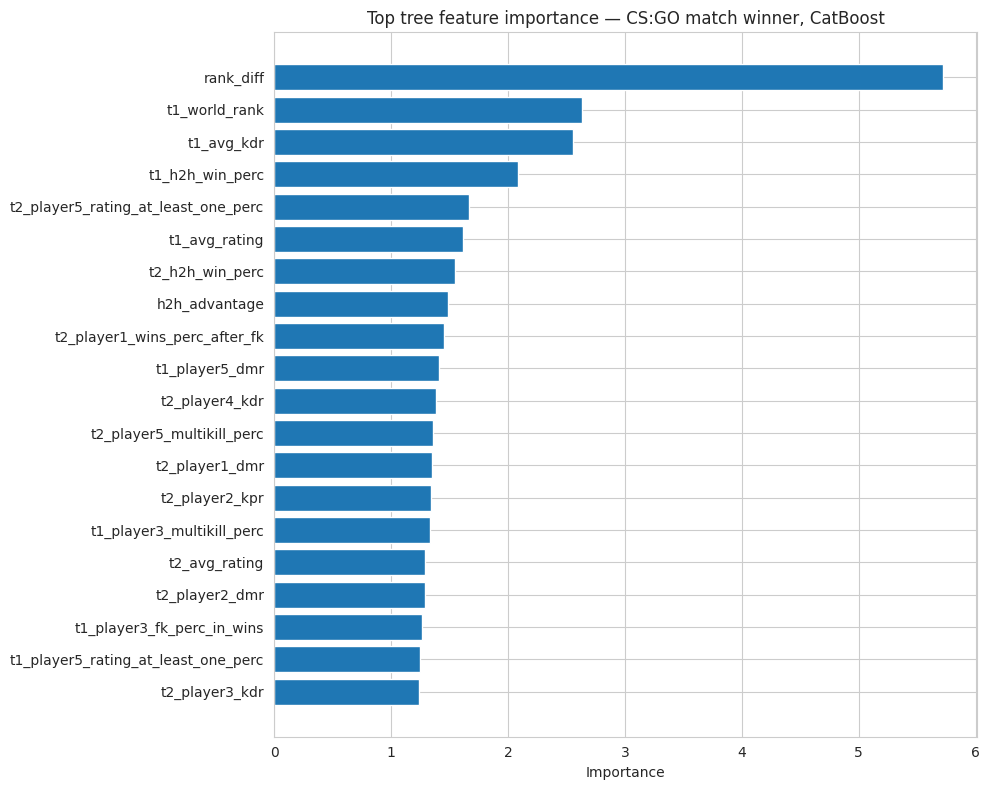


Top 20 Most Important Features:
                            feature  importance
                          rank_diff    5.723886
                      t1_world_rank    2.632016
                         t1_avg_kdr    2.555970
                    t1_h2h_win_perc    2.085928
t2_player5_rating_at_least_one_perc    1.670410
                      t1_avg_rating    1.613716
                    t2_h2h_win_perc    1.546436
                      h2h_advantage    1.483014
      t2_player1_wins_perc_after_fk    1.452812
                     t1_player5_dmr    1.407536
                     t2_player4_kdr    1.385707
          t2_player5_multikill_perc    1.357179
                     t2_player1_dmr    1.354149
                     t2_player2_kpr    1.345566
          t1_player3_multikill_perc    1.332299
                      t2_avg_rating    1.290067
                     t2_player2_dmr    1.289381
         t1_player3_fk_perc_in_wins    1.264517
t1_player5_rating_at_least_one_perc    1.246108
       

In [27]:
# CatBoost — CS:GO match winner

import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt


def train_basic_catboost(X_train, y_train, X_test, y_test):
    n_classes = len(np.unique(y_train))
    loss_function = "MultiClass" if n_classes > 2 else "Logloss"

    catboost_basic = CatBoostClassifier(
        iterations=500,
        learning_rate=0.1,
        depth=6,
        loss_function=loss_function,
        eval_metric="Accuracy",
        random_seed=42,
        verbose=False,
    )

    print("Training CatBoost...")
    catboost_basic.fit(X_train, y_train, eval_set=(X_test, y_test), verbose=False)

    y_pred_basic = np.asarray(catboost_basic.predict(X_test)).ravel().astype(int)

    if len(np.unique(y_test)) > 2:
        accuracy_basic = accuracy_score(y_test, y_pred_basic)
        precision_basic = precision_score(y_test, y_pred_basic, average="macro", zero_division=0)
        recall_basic = recall_score(y_test, y_pred_basic, average="macro", zero_division=0)
        f1_basic = f1_score(y_test, y_pred_basic, average="macro", zero_division=0)
        nu = len(np.unique(y_test))
        if nu == 3:
            target_names = ["Team 2", "Team 1", "Other"]
        else:
            target_names = [str(int(x)) for x in sorted(np.unique(y_test))]
    else:
        accuracy_basic = accuracy_score(y_test, y_pred_basic)
        precision_basic = precision_score(y_test, y_pred_basic, average="binary", zero_division=0)
        recall_basic = recall_score(y_test, y_pred_basic, average="binary", zero_division=0)
        f1_basic = f1_score(y_test, y_pred_basic, average="binary", zero_division=0)
        target_names = ["Team 2", "Team 1"]

    print(f"\n✓ Basic CatBoost Accuracy: {accuracy_basic:.4f} ({accuracy_basic*100:.2f}%)")
    print(f"  Precision: {precision_basic:.4f}")
    print(f"  Recall: {recall_basic:.4f}")
    print(f"  F1-Score: {f1_basic:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_basic, target_names=target_names, zero_division=0))

    plot_per_class_metrics_bars(
        y_test,
        y_pred_basic,
        "Per-class precision / recall / F1 — CS:GO match winner, CatBoost (test)",
    )

    plot_confusion_matrix(
        y_test,
        y_pred_basic,
        "Confusion matrix — CS:GO match winner, CatBoost (test)",
        cmap="BuPu",
    )

    feature_names = X_train.columns if hasattr(X_train, "columns") else [f"Feature_{i}" for i in range(X_train.shape[1])]
    imp = catboost_basic.get_feature_importance()
    plot_top_feature_importance(
        feature_names,
        imp,
        "Top tree feature importance — CS:GO match winner, CatBoost",
        top_n=20,
        figsize=(10, 8),
    )

    importance_df = (
        pd.DataFrame({"feature": feature_names, "importance": imp})
        .sort_values("importance", ascending=False)
        .head(20)
    )
    print("\nTop 20 Most Important Features:")
    print(importance_df.to_string(index=False))

    return catboost_basic, accuracy_basic


def run_catboost(X_train, y_train, X_test, y_test):
    print("\n Training Basic CatBoost...")
    return train_basic_catboost(X_train, y_train, X_test, y_test)


cb_results = run_catboost(X_train, y_train, X_test, y_test)


## 1.1.5 Model Evaluation


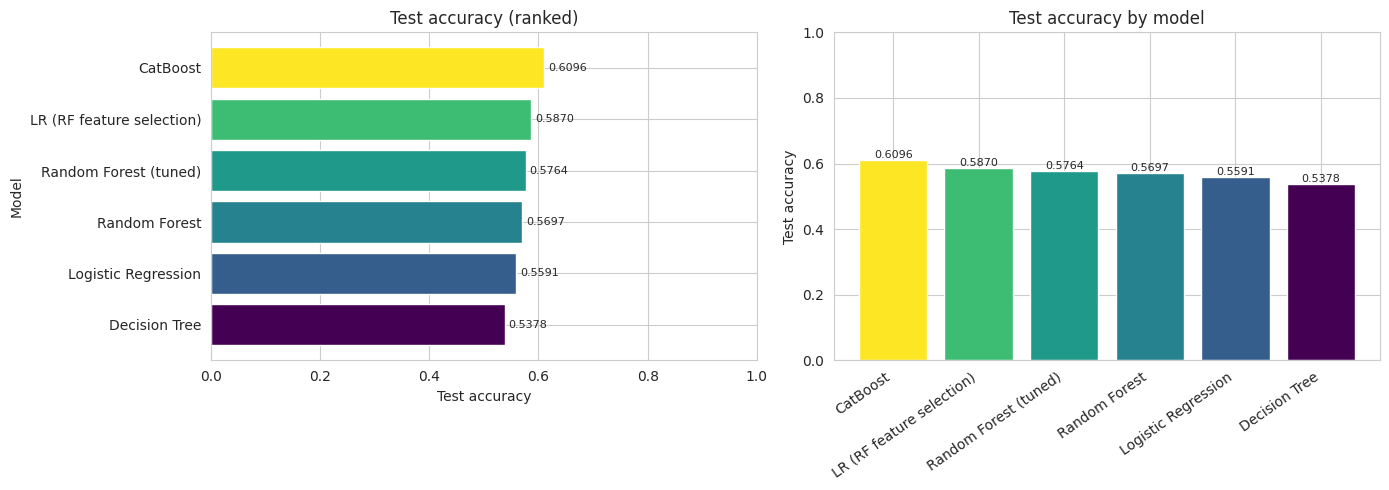


Test accuracy summary (sorted, high to low):
                    model  accuracy
                 CatBoost  0.609562
LR (RF feature selection)  0.586985
    Random Forest (tuned)  0.576361
            Random Forest  0.569721
      Logistic Regression  0.559097
            Decision Tree  0.537849


In [28]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def compare_model_accuracies(plot=True):
    """Compare test accuracies from earlier cells using stored variables (no retraining).

    Uses: lr_accuracy, dt_accuracy, rf_accuracy, lr_selected_accuracy,
    rf_tuned_accuracy, and CatBoost accuracy from cb_results[1].
    """
    rows = [
        ("Logistic Regression", lr_accuracy),
        ("Decision Tree", dt_accuracy),
        ("Random Forest", rf_accuracy),
        ("LR (RF feature selection)", lr_selected_accuracy),
        ("Random Forest (tuned)", rf_tuned_accuracy),
        ("CatBoost", cb_results[1]),
    ]
    df = pd.DataFrame(rows, columns=["model", "accuracy"])
    df = df.sort_values("accuracy", ascending=False).reset_index(drop=True)

    if plot:
        acc = df["accuracy"].values
        lo, hi = acc.min(), acc.max()
        span = hi - lo
        norm = (acc - lo) / span if span > 0 else np.full(len(acc), 0.5)
        colors = plt.cm.viridis(norm)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        bars_h = ax1.barh(df["model"], df["accuracy"], color=colors)
        ax1.set_xlabel("Test accuracy")
        ax1.set_ylabel("Model")
        ax1.set_title("Test accuracy (ranked)")
        ax1.set_xlim(0, max(1.0, df["accuracy"].max() * 1.08))
        ax1.bar_label(bars_h, fmt="%.4f", padding=3, fontsize=8)
        ax1.invert_yaxis()

        x = np.arange(len(df))
        bars_v = ax2.bar(x, df["accuracy"], color=colors)
        ax2.set_xticks(x)
        ax2.set_xticklabels(df["model"], rotation=35, ha="right")
        ax2.set_ylabel("Test accuracy")
        ax2.set_title("Test accuracy by model")
        ax2.set_ylim(0, max(1.0, df["accuracy"].max() * 1.12))
        ax2.bar_label(bars_v, fmt="%.4f", fontsize=8)

        plt.tight_layout()
        plt.show()

    return df


accuracy_summary = compare_model_accuracies()
print("\nTest accuracy summary (sorted, high to low):")
print(accuracy_summary.to_string(index=False))
